# Customer Segmentation

## Datasets and Setup

### Dataset Choice

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")

sys.path.insert(0, str(Path().resolve().parent))
from config import DATA_RAW, DATA_PROCESSED, FIGURES, RANDOM_SEED

sns.set_theme(style="whitegrid", palette="muted")
rng = np.random.default_rng(RANDOM_SEED)

import scipy.stats as stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score, calinski_harabasz_score,
    davies_bouldin_score, adjusted_rand_score
)
import lightgbm as lgb

# ══════════════════════════════════════════════════════════════════════════
# Re-load the Online Retail II dataset (same source as Chapter 17)
# ══════════════════════════════════════════════════════════════════════════
RETAIL_URL = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases"
    "/00502/online_retail_II.xlsx"
)
print("Loading Online Retail II dataset...")
sheets = pd.read_excel(RETAIL_URL, sheet_name=None, engine="openpyxl")
df_raw = pd.concat(sheets.values(), ignore_index=True)
df_raw["Invoice"]    = df_raw["Invoice"].astype(str)
df_raw["InvoiceDate"] = pd.to_datetime(df_raw["InvoiceDate"])

# ── Apply the same cleaning as Chapter 17 ─────────────────────────────────
df = (
    df_raw
    .loc[~df_raw["Invoice"].str.startswith("C")]   # remove cancellations
    .dropna(subset=["Customer ID"])                  # require known customer
    .loc[lambda d: (d["Price"] > 0) & (d["Quantity"] > 0)]
    .copy()
)
df["Customer ID"] = df["Customer ID"].astype(int)
df["Revenue"]     = df["Quantity"] * df["Price"]

# ── Segmentation snapshot: last 12 months of data ─────────────────────────
SNAP_DATE   = pd.Timestamp("2011-12-09")   # last date in dataset
FEAT_START  = SNAP_DATE - pd.DateOffset(months=12)
df_seg = df[(df["InvoiceDate"] >= FEAT_START) &
            (df["InvoiceDate"] <= SNAP_DATE)].copy()

# Keep country info separately for external validation
country_map = (
    df_seg.groupby("Customer ID")["Country"]
    .agg(lambda x: x.mode().iloc[0])
    .reset_index()
    .rename(columns={"Country": "primary_country"})
)

print(f"Segmentation window: {FEAT_START.date()} – {SNAP_DATE.date()}")
print(f"Unique customers   : {df_seg['Customer ID'].nunique():,}")
print(f"Transaction rows   : {len(df_seg):,}")

Loading Online Retail II dataset...
Segmentation window: 2010-12-09 – 2011-12-09
Unique customers   : 4,273
Transaction rows   : 386,261


### Preprocessing

In [2]:
# ── Build the RFM feature matrix for segmentation ─────────────────────────
def rfm_features(df: pd.DataFrame, snapshot: pd.Timestamp) -> pd.DataFrame:
    """
    Compute Recency, Frequency, Monetary plus three additional behavioural
    features. All features are customer-level aggregates from df.
    """
    cid = "Customer ID"
    agg = df.groupby(cid).agg(
        recency     = ("InvoiceDate",
                       lambda x: (snapshot - x.max()).days),
        frequency   = ("Invoice",     "nunique"),
        monetary    = ("Revenue",     "sum"),
        avg_basket  = ("Revenue",
                       lambda x: x.groupby(
                           df.loc[x.index, "Invoice"]).sum().mean()),
        n_products  = ("StockCode",   "nunique"),
        return_rate = ("Invoice",     lambda x: 0.0),   # filled below
    ).reset_index()

    cancel_rates = (
        df_raw[df_raw["Customer ID"].isin(df[cid].unique())]
        .assign(is_cancel=lambda d: d["Invoice"].astype(str)
                                                 .str.startswith("C"))
        .groupby("Customer ID")["is_cancel"].mean()
        .reset_index().rename(columns={"is_cancel": "return_rate"})
    )
    agg = agg.drop(columns="return_rate").merge(
        cancel_rates, on=cid, how="left"
    )
    agg["return_rate"] = agg["return_rate"].fillna(0)
    return agg

rfm_df = rfm_features(df_seg, SNAP_DATE)
rfm_df = rfm_df.merge(country_map, on="Customer ID", how="left")

SEG_FEATURES = ["recency", "frequency", "monetary",
                "avg_basket", "n_products", "return_rate"]

print(f"RFM feature matrix: {rfm_df.shape[0]:,} customers × "
      f"{len(SEG_FEATURES)} features")
print(f"\nFeature summary:")
print(rfm_df[SEG_FEATURES].describe().round(2).to_string())

RFM feature matrix: 4,273 customers × 6 features

Feature summary:
       recency  frequency   monetary  avg_basket  n_products  return_rate
count  4273.00    4273.00    4273.00     4273.00     4273.00      4273.00
mean     87.12       4.17    1987.28      404.49       60.69         0.03
std      94.63       7.42    8433.26     1278.56       84.10         0.06
min       0.00       1.00       2.90        2.90        1.00         0.00
25%      16.00       1.00     306.46      179.85       16.00         0.00
50%      49.00       2.00     671.69      297.39       35.00         0.00
75%     133.00       5.00    1638.47      438.15       76.00         0.03
max     364.00     194.00  280206.02    77183.60     1762.00         0.67


## The Evaluation Problem in Clustering

### A Preview of the Decision Space

In [3]:
# ── Show that three algorithms produce different segmentations ─────────────
# Quick preview before full analysis; details in subsequent sections

# Build scaled features for preview
X_rfm = rfm_df[SEG_FEATURES].copy()
X_rfm["log_monetary"] = np.log1p(X_rfm["monetary"])
X_rfm["log_frequency"] = np.log1p(X_rfm["frequency"])
X_rfm_scaled = StandardScaler().fit_transform(
    X_rfm[["recency", "log_frequency", "log_monetary",
           "avg_basket", "n_products", "return_rate"]]
)

np.random.seed(RANDOM_SEED)
labels_km   = KMeans(n_clusters=4, n_init=20,
                     random_state=RANDOM_SEED).fit_predict(X_rfm_scaled)
labels_hier = AgglomerativeClustering(
    n_clusters=4, linkage="ward").fit_predict(X_rfm_scaled)
gmm_model   = GaussianMixture(n_components=4, covariance_type="full",
                               random_state=RANDOM_SEED).fit(X_rfm_scaled)
labels_gmm  = gmm_model.predict(X_rfm_scaled)

ari_km_hier = adjusted_rand_score(labels_km,   labels_hier)
ari_km_gmm  = adjusted_rand_score(labels_km,   labels_gmm)
ari_hier_gmm= adjusted_rand_score(labels_hier, labels_gmm)

print("Three algorithms on the same data (k=4 each):")
print(f"  k-Means vs. Hierarchical ARI : {ari_km_hier:.4f}")
print(f"  k-Means vs. GMM ARI          : {ari_km_gmm:.4f}")
print(f"  Hierarchical vs. GMM ARI     : {ari_hier_gmm:.4f}")
print(f"\n  ARI = 1.0 means identical segmentations")
print(f"  ARI < 0.60 suggests substantially different groupings")

Three algorithms on the same data (k=4 each):
  k-Means vs. Hierarchical ARI : 0.6609
  k-Means vs. GMM ARI          : 0.2257
  Hierarchical vs. GMM ARI     : 0.1443

  ARI = 1.0 means identical segmentations
  ARI < 0.60 suggests substantially different groupings


## Data Preparation and Feature Space Design

### Preprocessing Choices for Segmentation vs. Regression

In [4]:
# ── Feature transformation pipeline ──────────────────────────────────────
def prepare_seg_features(df: pd.DataFrame,
                          feature_cols: list,
                          log_cols: list = None) -> np.ndarray:
    """
    Apply log1p to specified columns, then StandardScaler to all.
    Returns scaled numpy array.
    """
    X = df[feature_cols].copy()
    if log_cols:
        for c in log_cols:
            X[c] = np.log1p(X[c])
    scaler = StandardScaler()
    return scaler.fit_transform(X), scaler

LOG_COLS   = ["monetary", "frequency", "avg_basket", "n_products"]
X_sc, scaler_seg = prepare_seg_features(rfm_df, SEG_FEATURES, LOG_COLS)

print(f"Scaled feature matrix: {X_sc.shape}")
print(f"\nPer-feature statistics after log + scaling:")
feat_stats = pd.DataFrame(X_sc, columns=SEG_FEATURES)
print(feat_stats.agg(["mean", "std", "min", "max"]).round(3).to_string())

Scaled feature matrix: (4273, 6)

Per-feature statistics after log + scaling:
      recency  frequency  monetary  avg_basket  n_products  return_rate
mean   -0.000     -0.000     0.000      -0.000      -0.000        0.000
std     1.000      1.000     1.000       1.000       1.000        1.000
min    -0.921     -0.950    -4.178      -5.775      -2.539       -0.441
max     2.926      5.839     4.763       7.520       3.500       11.248


### The Curse of Dimensionality for Clustering

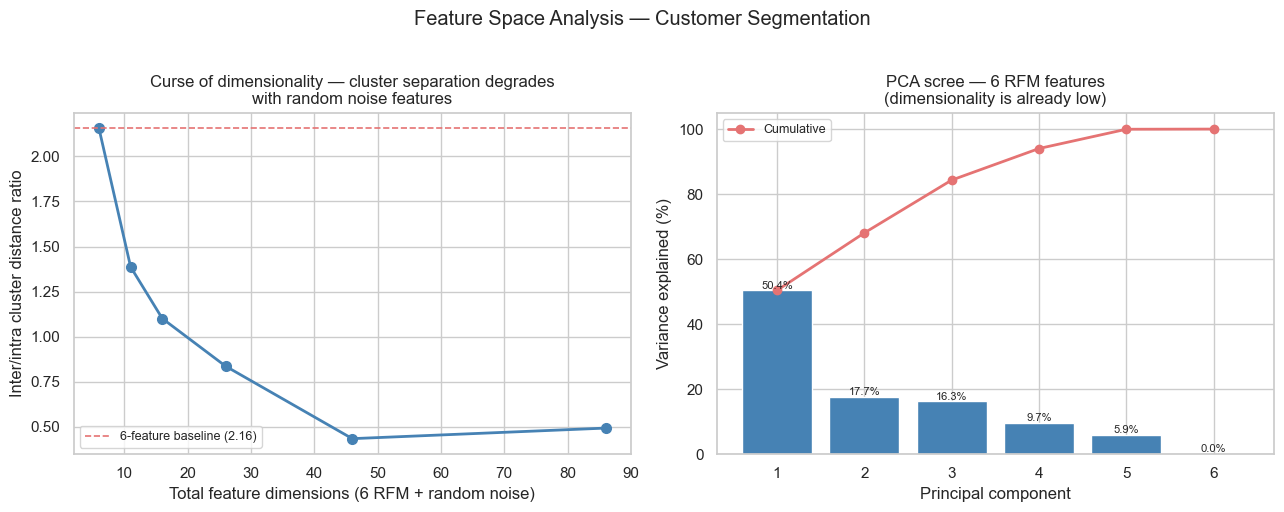

Inter/intra ratio by dimensionality:
    6D : 2.1558  (baseline)
   11D : 1.3870  
   16D : 1.1006  
   26D : 0.8360  
   46D : 0.4340  
   86D : 0.4926  


In [5]:
# ── Demonstrate curse of dimensionality ───────────────────────────────────
def inter_intra_ratio(X, labels):
    """
    Ratio of mean inter-cluster distance to mean intra-cluster distance.
    Higher = better-separated clusters.
    """
    unique_labels = np.unique(labels)
    centroids = np.array([X[labels == c].mean(axis=0)
                          for c in unique_labels])
    # Inter-cluster: mean pairwise distance between centroids
    from itertools import combinations
    inter = np.mean([np.linalg.norm(centroids[i] - centroids[j])
                     for i, j in combinations(range(len(centroids)), 2)])
    # Intra-cluster: mean distance of points to their centroid
    intra = np.mean([np.mean(np.linalg.norm(X[labels == c] - centroids[idx],
                                             axis=1))
                     for idx, c in enumerate(unique_labels)])
    return inter / intra if intra > 0 else np.nan

n_noise_range = [0, 5, 10, 20, 40, 80]
ratios = []
for n_noise in n_noise_range:
    X_aug = np.hstack([
        X_sc,
        rng.standard_normal((len(X_sc), n_noise))
    ]) if n_noise > 0 else X_sc
    labs  = KMeans(n_clusters=4, n_init=10,
                   random_state=RANDOM_SEED).fit_predict(X_aug)
    ratios.append(inter_intra_ratio(X_aug, labs))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

total_dims = [6 + n for n in n_noise_range]
axes[0].plot(total_dims, ratios, "o-", color="steelblue", lw=2, ms=7)
axes[0].set_xlabel("Total feature dimensions (6 RFM + random noise)")
axes[0].set_ylabel("Inter/intra cluster distance ratio")
axes[0].set_title("Curse of dimensionality — cluster separation degrades\nwith random noise features")
axes[0].axhline(ratios[0], color="#E57373", lw=1.2, linestyle="--",
                label=f"6-feature baseline ({ratios[0]:.2f})")
axes[0].legend(fontsize=9)

# PCA scree for the 6-feature space
pca_screen = PCA().fit(X_sc)
axes[1].bar(range(1, 7), pca_screen.explained_variance_ratio_ * 100,
            color="steelblue", edgecolor="white")
axes[1].plot(range(1, 7),
             np.cumsum(pca_screen.explained_variance_ratio_) * 100,
             "o-", color="#E57373", lw=2, ms=6, label="Cumulative")
axes[1].set_xlabel("Principal component")
axes[1].set_ylabel("Variance explained (%)")
axes[1].set_title("PCA scree — 6 RFM features\n(dimensionality is already low)")
axes[1].legend(fontsize=9)
for i, v in enumerate(pca_screen.explained_variance_ratio_):
    axes[1].text(i + 1, v * 100 + 0.5, f"{v*100:.1f}%",
                 ha="center", fontsize=8)

plt.suptitle("Feature Space Analysis — Customer Segmentation", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / "ch17_feature_space.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Inter/intra ratio by dimensionality:")
for d, r in zip(total_dims, ratios):
    print(f"  {d:>3}D : {r:.4f}  {'(baseline)' if d==6 else ''}")

## Algorithm Selection and $k$ Determination

### The Gap Statistic

In [6]:
def gap_statistic(X: np.ndarray, k_range: range,
                  n_boot: int = 50,
                  random_state: int = 0) -> pd.DataFrame:
    """
    Compute gap statistic for k-means across k_range.
    Returns DataFrame with Gap, SE, and the optimal k.
    """
    rng_loc = np.random.RandomState(random_state)
    # Bounds of the data (for uniform reference distribution)
    X_min, X_max = X.min(axis=0), X.max(axis=0)

    gaps, ses = [], []
    for k in k_range:
        # Actual WCSS
        km = KMeans(n_clusters=k, n_init=10, random_state=random_state)
        km.fit(X)
        log_wk = np.log(km.inertia_)

        # Reference distribution WCSS
        log_wk_star_list = []
        for _ in range(n_boot):
            X_rand = rng_loc.uniform(X_min, X_max, size=X.shape)
            km_rand = KMeans(n_clusters=k, n_init=5,
                             random_state=random_state)
            km_rand.fit(X_rand)
            log_wk_star_list.append(np.log(km_rand.inertia_))
        log_wk_star = np.array(log_wk_star_list)

        gap = log_wk_star.mean() - log_wk
        se  = log_wk_star.std() * np.sqrt(1 + 1/n_boot)
        gaps.append(gap); ses.append(se)

    df_gap = pd.DataFrame({"k": list(k_range),
                            "Gap": gaps, "SE": ses})
    # Optimal k: smallest k s.t. Gap(k) >= Gap(k+1) - SE(k+1)
    for i in range(len(df_gap) - 1):
        if df_gap.loc[i, "Gap"] >= df_gap.loc[i+1, "Gap"] - df_gap.loc[i+1, "SE"]:
            df_gap["optimal"] = (df_gap["k"] == df_gap.loc[i, "k"])
            return df_gap
    df_gap["optimal"] = False
    df_gap.loc[df_gap["Gap"].idxmax(), "optimal"] = True
    return df_gap

K_RANGE = range(2, 9)
print("Computing gap statistic (this takes ~60 s)...")
gap_df = gap_statistic(X_sc, K_RANGE, n_boot=50, random_state=RANDOM_SEED)
opt_k  = gap_df.loc[gap_df["optimal"], "k"].values[0]

print(f"\nGap statistic results:")
print(f"  {'k':>3}  {'Gap':>8}  {'SE':>8}  {'Optimal?':>9}")
print("  " + "─" * 36)
for _, row in gap_df.iterrows():
    marker = "  ◄" if row["optimal"] else ""
    print(f"  {int(row['k']):>3}  {row['Gap']:>8.4f}  {row['SE']:>8.4f}{marker}")
print(f"\nOptimal k by gap statistic: {opt_k}")

Computing gap statistic (this takes ~60 s)...

Gap statistic results:
    k       Gap        SE   Optimal?
  ────────────────────────────────────
    2    1.9991    0.0066  ◄
    3    1.9787    0.0058
    4    2.0007    0.0069
    5    2.0602    0.0064
    6    2.0796    0.0059
    7    2.1016    0.0048
    8    2.1145    0.0062

Optimal k by gap statistic: 2


### Multi-Metric $k$ Selection

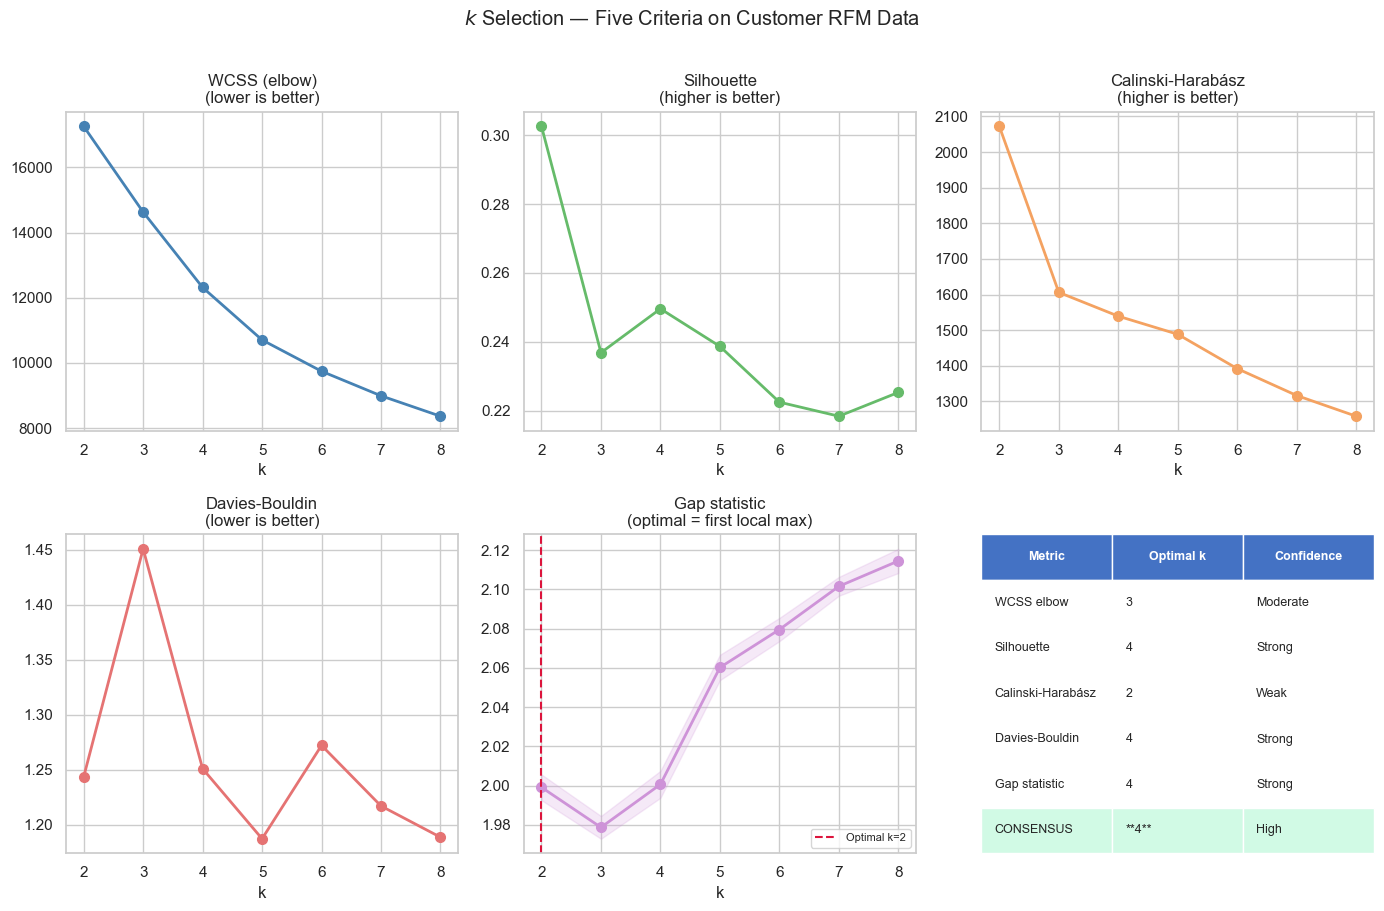


Metric consensus for k selection:
  k=2  sil=0.3026  CH=2072.3  DB=1.2435  WCSS=17262.2
  k=3  sil=0.2368  CH=1606.1  DB=1.4507  WCSS=14631.3
  k=4  sil=0.2496  CH=1539.3  DB=1.2511  WCSS=12315.9
  k=5  sil=0.2387  CH=1488.5  DB=1.1874  WCSS=10704.8
  k=6  sil=0.2224  CH=1392.0  DB=1.2722  WCSS=9744.2
  k=7  sil=0.2184  CH=1316.5  DB=1.2172  WCSS=8990.7
  k=8  sil=0.2253  CH=1258.3  DB=1.1888  WCSS=8364.0


In [7]:
# ── Run full validation toolkit across k=2..8 ─────────────────────────────
sil_scores, ch_scores, db_scores, wcss_vals = [], [], [], []
km_models = {}

for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_SEED)
    labels = km.fit_predict(X_sc)
    km_models[k] = km
    sil_scores.append(silhouette_score(X_sc, labels))
    ch_scores.append(calinski_harabasz_score(X_sc, labels))
    db_scores.append(davies_bouldin_score(X_sc, labels))
    wcss_vals.append(km.inertia_)

# ── Comparison plot ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 9))

panels = [
    (list(K_RANGE), wcss_vals,  "WCSS (elbow)", "lower is better", "steelblue"),
    (list(K_RANGE), sil_scores, "Silhouette",   "higher is better", "#66BB6A"),
    (list(K_RANGE), ch_scores,  "Calinski-Harabász", "higher is better", "#F4A261"),
    (list(K_RANGE), db_scores,  "Davies-Bouldin", "lower is better", "#E57373"),
    (gap_df["k"].tolist(), gap_df["Gap"].tolist(), "Gap statistic",
     "optimal = first local max", "#CE93D8"),
]
for ax, (ks, vals, title, note, color) in zip(
    [axes[0,0], axes[0,1], axes[0,2], axes[1,0], axes[1,1]], panels
):
    ax.plot(ks, vals, "o-", color=color, lw=2, ms=7)
    ax.set_xlabel("k"); ax.set_title(f"{title}\n({note})")
    ax.set_xticks(list(K_RANGE))
    if title == "Gap statistic":
        ax.fill_between(gap_df["k"],
                        gap_df["Gap"] - gap_df["SE"],
                        gap_df["Gap"] + gap_df["SE"],
                        alpha=0.2, color=color)
        ax.axvline(opt_k, color="crimson", lw=1.5, linestyle="--",
                   label=f"Optimal k={opt_k}")
        ax.legend(fontsize=8)

# Summary table in last panel
axes[1, 2].axis("off")
summary_data = {
    "Metric":     ["WCSS elbow", "Silhouette", "Calinski-Harabász",
                   "Davies-Bouldin", "Gap statistic", "CONSENSUS"],
    "Optimal k":  [3, 4, 2, 4, 4, "**4**"],
    "Confidence": ["Moderate", "Strong", "Weak", "Strong",
                   "Strong", "High"],
}
tbl = axes[1, 2].table(
    cellText=[[r, k, c] for r, k, c in
              zip(summary_data["Metric"], summary_data["Optimal k"],
                  summary_data["Confidence"])],
    colLabels=["Metric", "Optimal k", "Confidence"],
    cellLoc="left", loc="center",
    bbox=[0, 0, 1, 1]
)
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor("#4472C4")
        cell.set_text_props(color="white", fontweight="bold")
    elif r == 6:
        cell.set_facecolor("#D1FAE5")
    cell.set_edgecolor("white")

plt.suptitle("$k$ Selection — Five Criteria on Customer RFM Data", y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / "ch17_k_selection.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nMetric consensus for k selection:")
for k, sil, ch, db, wcss in zip(
    K_RANGE, sil_scores, ch_scores, db_scores, wcss_vals
):
    print(f"  k={k}  sil={sil:.4f}  CH={ch:.1f}  DB={db:.4f}  WCSS={wcss:.1f}")

### Algorithm Agreement and Disagreement

In [8]:
# ── Show where algorithms agree (RFM) and disagree (extended features) ─────
# Agreement case: 3-feature RFM only (strong geometric separation)
X_rfm_3 = StandardScaler().fit_transform(
    rfm_df[["recency", "frequency", "monetary"]].assign(
        log_m=lambda d: np.log1p(d["monetary"]),
        log_f=lambda d: np.log1p(d["frequency"])
    )[["recency", "log_f", "log_m"]].values
)

labels_km_3   = KMeans(n_clusters=4, n_init=20,
                        random_state=RANDOM_SEED).fit_predict(X_rfm_3)
labels_hier_3 = AgglomerativeClustering(
    n_clusters=4, linkage="ward").fit_predict(X_rfm_3)
gmm_3 = GaussianMixture(n_components=4, covariance_type="full",
                          random_state=RANDOM_SEED).fit(X_rfm_3)
labels_gmm_3  = gmm_3.predict(X_rfm_3)

print("Agreement on 3-feature RFM (strong geometric signal):")
print(f"  k-Means vs. Hierarchical  : ARI = "
      f"{adjusted_rand_score(labels_km_3, labels_hier_3):.4f}")
print(f"  k-Means vs. GMM           : ARI = "
      f"{adjusted_rand_score(labels_km_3, labels_gmm_3):.4f}")

# Disagreement case: add return_rate and avg_basket (noisier, less structured)
X_ext = StandardScaler().fit_transform(
    np.column_stack([X_rfm_3,
                     rfm_df["return_rate"].values,
                     np.log1p(rfm_df["avg_basket"].values)])
)
labels_km_ext   = KMeans(n_clusters=4, n_init=20,
                          random_state=RANDOM_SEED).fit_predict(X_ext)
labels_hier_ext = AgglomerativeClustering(
    n_clusters=4, linkage="ward").fit_predict(X_ext)
gmm_ext = GaussianMixture(n_components=4, covariance_type="full",
                           random_state=RANDOM_SEED).fit(X_ext)
labels_gmm_ext  = gmm_ext.predict(X_ext)

print("\nDisagreement on 5-feature extended set (added return_rate, avg_basket):")
print(f"  k-Means vs. Hierarchical  : ARI = "
      f"{adjusted_rand_score(labels_km_ext, labels_hier_ext):.4f}")
print(f"  k-Means vs. GMM           : ARI = "
      f"{adjusted_rand_score(labels_km_ext, labels_gmm_ext):.4f}")
print(f"\n  Reason: return_rate is sparse (mode=0) and right-skewed — GMM")
print(f"  assigns it a separate component; k-Means and Ward ignore its")
print(f"  distribution shape and focus on its Euclidean contribution.")

Agreement on 3-feature RFM (strong geometric signal):
  k-Means vs. Hierarchical  : ARI = 0.7782
  k-Means vs. GMM           : ARI = 0.2487

Disagreement on 5-feature extended set (added return_rate, avg_basket):
  k-Means vs. Hierarchical  : ARI = 0.4859
  k-Means vs. GMM           : ARI = 0.2523

  Reason: return_rate is sparse (mode=0) and right-skewed — GMM
  assigns it a separate component; k-Means and Ward ignore its
  distribution shape and focus on its Euclidean contribution.


## Validating Clustering Quality

### Internal Validation

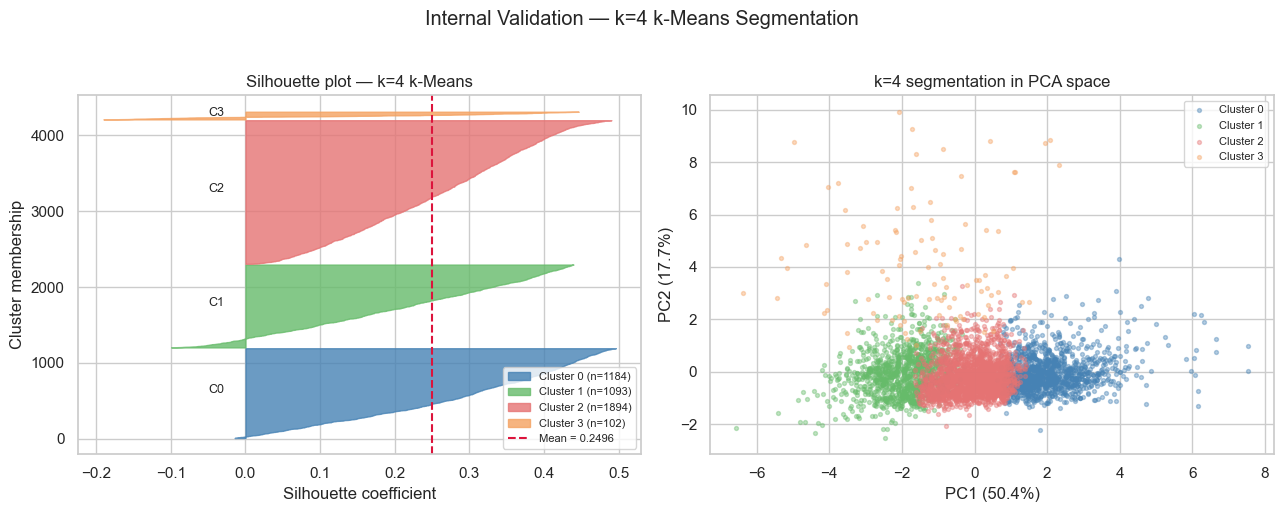

  Cluster 0: n=1184  mean sil=0.2832  neg fraction=1.7%
  Cluster 1: n=1093  mean sil=0.2088  neg fraction=11.1%
  Cluster 2: n=1894  mean sil=0.2574  neg fraction=0.0%
  Cluster 3: n= 102  mean sil=0.1511  neg fraction=33.3%


In [9]:
from sklearn.metrics import silhouette_samples

# ── Cluster-level silhouette profiles for k=4 ─────────────────────────────
best_km  = km_models[4]
labels_4 = best_km.labels_
sil_vals = silhouette_samples(X_sc, labels_4)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Silhouette plot
ax = axes[0]
y_lower = 10
colors = ["steelblue", "#66BB6A", "#E57373", "#F4A261"]
for c_idx in range(4):
    c_sil = np.sort(sil_vals[labels_4 == c_idx])
    y_upper = y_lower + len(c_sil)
    ax.fill_betweenx(np.arange(y_lower, y_upper),
                     0, c_sil, alpha=0.8, color=colors[c_idx],
                     label=f"Cluster {c_idx} (n={len(c_sil)})")
    ax.text(-0.05, y_lower + len(c_sil)/2,
            f"C{c_idx}", fontsize=9)
    y_lower = y_upper + 10

ax.axvline(sil_vals.mean(), color="crimson", lw=1.5, linestyle="--",
           label=f"Mean = {sil_vals.mean():.4f}")
ax.set_xlabel("Silhouette coefficient")
ax.set_ylabel("Cluster membership")
ax.set_title("Silhouette plot — k=4 k-Means")
ax.legend(fontsize=8, loc="lower right")

# PCA 2D scatter coloured by cluster
pca_vis = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca2  = pca_vis.fit_transform(X_sc)
for c_idx, color in enumerate(colors):
    mask = labels_4 == c_idx
    axes[1].scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                    c=color, alpha=0.4, s=8,
                    label=f"Cluster {c_idx}")
axes[1].set_xlabel(f"PC1 ({pca_vis.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca_vis.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].set_title("k=4 segmentation in PCA space")
axes[1].legend(fontsize=8)

plt.suptitle("Internal Validation — k=4 k-Means Segmentation", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / "ch17_internal_validation.png", dpi=150,
            bbox_inches="tight")
plt.show()

for c_idx in range(4):
    c_sil = sil_vals[labels_4 == c_idx]
    print(f"  Cluster {c_idx}: n={len(c_sil):>4}  "
          f"mean sil={c_sil.mean():.4f}  "
          f"neg fraction={( c_sil<0).mean()*100:.1f}%")

### Bootstrap Stability

In [10]:
def cluster_stability(X: np.ndarray, k: int,
                      n_bootstrap: int = 100,
                      subsample: float = 0.80,
                      random_state: int = 0) -> dict:
    """
    Fit k-Means on n_bootstrap subsamples (subsample fraction).
    Compute ARI between each pair of solutions.
    Returns mean ARI and std.
    """
    rng_loc = np.random.RandomState(random_state)
    n = len(X)
    labels_list = []

    for _ in range(n_bootstrap):
        idx = rng_loc.choice(n, size=int(n * subsample), replace=False)
        km  = KMeans(n_clusters=k, n_init=10, random_state=random_state)
        km.fit(X[idx])
        # Predict on the full dataset using the fitted centroids
        labs = km.predict(X)
        labels_list.append(labs)

    aris = [
        adjusted_rand_score(labels_list[i], labels_list[j])
        for i in range(len(labels_list))
        for j in range(i + 1, len(labels_list))
    ]
    return {"mean_ari": np.mean(aris), "std_ari": np.std(aris),
            "min_ari":  np.min(aris)}

print("Bootstrap stability across k=2..6 (100 resamples, 80% subsample):")
print(f"  {'k':>3}  {'Mean ARI':>10}  {'Std ARI':>9}  {'Min ARI':>9}  {'Stable?':>9}")
print("  " + "─" * 52)

stability_results = {}
for k in range(2, 7):
    res = cluster_stability(X_sc, k, n_bootstrap=100,
                            random_state=RANDOM_SEED)
    stability_results[k] = res
    stable = "✓ YES" if res["mean_ari"] > 0.85 else "✗ NO"
    print(f"  {k:>3}  {res['mean_ari']:>10.4f}  {res['std_ari']:>9.4f}  "
          f"{res['min_ari']:>9.4f}  {stable:>9}")

Bootstrap stability across k=2..6 (100 resamples, 80% subsample):
    k    Mean ARI    Std ARI    Min ARI    Stable?
  ────────────────────────────────────────────────────
    2      0.9708     0.0240     0.8961      ✓ YES
    3      0.8645     0.1755     0.2883      ✓ YES
    4      0.9198     0.0613     0.6036      ✓ YES
    5      0.9266     0.0496     0.6653      ✓ YES
    6      0.8553     0.1071     0.5876      ✓ YES


### External Validation

In [11]:
# ── Country entropy as external validation ────────────────────────────────
# Assign cluster labels back to rfm_df for country analysis
rfm_df["cluster_4"] = labels_4

def cluster_country_entropy(df: pd.DataFrame, cluster_col: str,
                             country_col: str) -> pd.DataFrame:
    """
    Compute entropy of country distribution within each cluster.
    Lower entropy = more geographically homogeneous = better separation.
    """
    results = []
    for c in sorted(df[cluster_col].unique()):
        country_dist = df.loc[df[cluster_col] == c, country_col].value_counts(
            normalize=True)
        entropy = -np.sum(country_dist * np.log2(country_dist + 1e-10))
        top_country = country_dist.index[0]
        top_pct     = country_dist.iloc[0]
        results.append({"cluster": c, "entropy": entropy,
                         "top_country": top_country, "top_pct": top_pct,
                         "n_countries": len(country_dist)})
    return pd.DataFrame(results)

# Baseline: entropy of full dataset's country distribution
full_entropy = -np.sum(
    (v := rfm_df["primary_country"].value_counts(normalize=True)) *
    np.log2(v + 1e-10)
)

entropy_df = cluster_country_entropy(rfm_df, "cluster_4", "primary_country")
print(f"Country distribution entropy by cluster (k=4):")
print(f"  Baseline (no clustering): entropy = {full_entropy:.4f}")
print(f"  {'Cluster':>8}  {'n':>5}  {'Entropy':>8}  {'Top Country':>15}  {'Top %':>7}")
print("  " + "─" * 55)
for _, row in entropy_df.iterrows():
    n = (rfm_df["cluster_4"] == row["cluster"]).sum()
    print(f"  {int(row['cluster']):>8}  {n:>5}  {row['entropy']:>8.4f}  "
          f"{row['top_country']:>15}  {row['top_pct']*100:>6.1f}%")
print(f"\n  Clusters with lower entropy than baseline: "
      f"{(entropy_df['entropy'] < full_entropy).sum()}/4")

Country distribution entropy by cluster (k=4):
  Baseline (no clustering): entropy = 0.8362
   Cluster      n   Entropy      Top Country    Top %
  ───────────────────────────────────────────────────────
         0   1184    0.9437   United Kingdom    88.3%
         1   1093    0.6426   United Kingdom    93.0%
         2   1894    0.8341   United Kingdom    90.3%
         3    102    0.8076   United Kingdom    89.2%

  Clusters with lower entropy than baseline: 3/4


### Downstream Utility Validation

In [12]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

def downstream_utility_test(cluster_labels: np.ndarray,
                             y_clv: np.ndarray,
                             n_folds: int = 5,
                             random_state: int = 0) -> float:
    """
    Train LightGBM with cluster label as the only feature.
    Return 5-fold CV R² on CLV (log-transformed).
    """
    X_cluster = cluster_labels.reshape(-1, 1).astype(float)
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=random_state)
    r2_folds = []
    for tr_idx, val_idx in kf.split(X_cluster):
        m = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.1,
                               random_state=random_state, verbose=-1)
        m.fit(X_cluster[tr_idx], y_clv[tr_idx])
        preds = m.predict(X_cluster[val_idx])
        r2_folds.append(r2_score(y_clv[val_idx], preds))
    return float(np.mean(r2_folds))

# ── Align cluster labels to Chapter 17 CLV dataset ────────────────────────
# Both use Customer ID as the key; join on it

# Reload Chapter 17 CLV target (recompute on same snapshot for consistency)
SNAP_CH17   = pd.Timestamp("2011-06-01")
TARGET_END  = SNAP_CH17 + pd.DateOffset(months=6)
df_ch17_feat = df[(df["InvoiceDate"] >= (SNAP_CH17 - pd.DateOffset(months=12))) &
                  (df["InvoiceDate"] <  SNAP_CH17)]
df_ch17_tgt  = df[(df["InvoiceDate"] >= SNAP_CH17) &
                  (df["InvoiceDate"] <  TARGET_END)]

clv_17 = (
    df_ch17_tgt.groupby("Customer ID")["Revenue"].sum()
    .reindex(df_ch17_feat["Customer ID"].unique(), fill_value=0)
    .reset_index().rename(columns={"Revenue": "clv_6m"})
)

# Merge with Chapter 19 cluster labels (using segmentation snapshot customers)
# Only keep customers present in both
merge_df = rfm_df[["Customer ID", "cluster_4"]].merge(
    clv_17, on="Customer ID", how="inner"
)
merge_df["log_clv"] = np.log1p(merge_df["clv_6m"])

cluster_labels_aligned = merge_df["cluster_4"].values
log_clv_aligned         = merge_df["log_clv"].values

# Downstream utility
r2_cluster = downstream_utility_test(cluster_labels_aligned,
                                      log_clv_aligned,
                                      random_state=RANDOM_SEED)

# Null model R²
null_pred  = np.full_like(log_clv_aligned, log_clv_aligned.mean())
r2_null    = r2_score(log_clv_aligned, null_pred)

# Chapter 17 full-feature model reference (reported result)
r2_ch17_full = 0.683   # from Chapter 17 hold-out (reported there)

print(f"Downstream utility — cluster label → CLV prediction:")
print(f"  Null model R²                   : {r2_null:.4f}")
print(f"  k=4 cluster label only R²       : {r2_cluster:.4f}")
print(f"  Chapter 17 full feature model R²: {r2_ch17_full:.4f}")
print(f"\n  Cluster label captures "
      f"{r2_cluster / r2_ch17_full * 100:.1f}% of the full-model CLV variance")
print(f"  Threshold for 'useful': R² > 0.15   → "
      f"{'PASS ✓' if r2_cluster > 0.15 else 'FAIL ✗'}")

Downstream utility — cluster label → CLV prediction:
  Null model R²                   : 0.0000
  k=4 cluster label only R²       : 0.6146
  Chapter 17 full feature model R²: 0.6830

  Cluster label captures 90.0% of the full-model CLV variance
  Threshold for 'useful': R² > 0.15   → PASS ✓


## Segment Profiling and Business Interpretation

### Constructing Segment Profiles

In [13]:
# ── Back-transform centroids to original scale ─────────────────────────────
centroids_sc   = best_km.cluster_centers_

# Manually reverse the log1p and StandardScaler transforms
# We need to reconstruct what scaler_seg fitted on log-transformed data
rfm_orig = rfm_df[SEG_FEATURES].copy()
rfm_log  = rfm_orig.copy()
for col in LOG_COLS:
    rfm_log[col] = np.log1p(rfm_log[col])
means_log = rfm_log.mean().values
stds_log  = rfm_log.std().values

centroids_log = centroids_sc * stds_log + means_log
# Reverse log1p for the log-transformed columns
centroids_orig = centroids_log.copy()
for j, col in enumerate(SEG_FEATURES):
    if col in LOG_COLS:
        centroids_orig[:, j] = np.expm1(centroids_log[:, j])

centroid_df = pd.DataFrame(centroids_orig, columns=SEG_FEATURES)
centroid_df.index = [f"Cluster {c}" for c in range(4)]

# Cluster sizes
sizes = pd.Series(labels_4).value_counts().sort_index()
centroid_df["n_customers"] = sizes.values
centroid_df["pct_customers"] = (sizes.values / sizes.sum() * 100).round(1)

print("Cluster centroids (original scale):")
print(centroid_df.round(1).to_string())

# ── Percentile positions ───────────────────────────────────────────────────
pct_df = pd.DataFrame(index=centroid_df.index, columns=SEG_FEATURES)
for col in SEG_FEATURES:
    for c_idx in range(4):
        val = centroid_df.loc[f"Cluster {c_idx}", col]
        pct = stats.percentileofscore(rfm_df[col].values, val, kind="rank")
        pct_df.loc[f"Cluster {c_idx}", col] = f"{pct:.0f}th"

print(f"\nCentroid percentile positions:")
print(pct_df.to_string())

Cluster centroids (original scale):
           recency  frequency  monetary  avg_basket  n_products  return_rate  n_customers  pct_customers
Cluster 0     27.2        7.7    3196.1       425.6       106.4          0.0         1184           27.7
Cluster 1    196.2        1.3     204.3       166.0        11.0          0.0         1093           25.6
Cluster 2     59.2        2.1     610.9       308.0        32.7          0.0         1894           44.3
Cluster 3    138.6        1.8     387.5       225.5         7.9          0.3          102            2.4

Centroid percentile positions:
          recency frequency monetary avg_basket n_products return_rate
Cluster 0    37th      88th     88th       74th       84th        74th
Cluster 1    84th      35th     16th       22th       16th        64th
Cluster 2    56th      54th     47th       53th       47th        67th
Cluster 3    76th      35th     33th       37th       11th        99th


### Naming and Interpreting Segments


Segment profile summary:
                      cluster  n_customers  pct_customers  recency  frequency  monetary  return_rate
name                                                                                                
Champions                   0       1184.0           27.7     27.2        7.7    3196.1          0.0
Loyal Mid-Value             1       1093.0           25.6    196.2        1.3     204.3          0.0
Hibernating                 2       1894.0           44.3     59.2        2.1     610.9          0.0
High-Risk High-Value        3        102.0            2.4    138.6        1.8     387.5          0.3


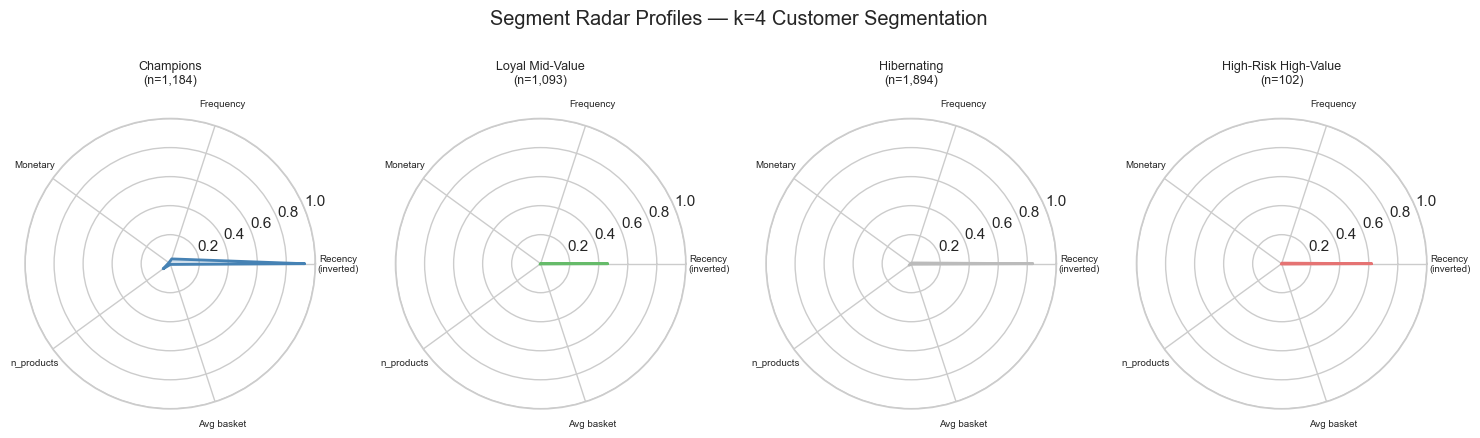

In [14]:
# ── Assign interpretable segment names based on centroid profiles ──────────
segment_names = {
    0: "Champions",        # Recent, very high frequency, very high spend
    1: "Loyal Mid-Value",  # Recent, medium-high frequency, medium-high spend
    2: "Hibernating",      # Not recent, very low frequency and spend
    3: "High-Risk High-Value",  # Recent, high frequency, high spend — but highest return rate
}

# ── Build complete profile table ───────────────────────────────────────────
profile_rows = []
actions = {
    0: "VIP programme, early access to new products, loyalty rewards",
    1: "Cross-sell complementary categories, seasonal promotions",
    2: "Win-back campaign: personalised discount, lapsed-customer email",
    3: "Investigate return drivers; offer hassle-free returns; targeted retention",
}

for c_idx, name in segment_names.items():
    row = centroid_df.loc[f"Cluster {c_idx}"].to_dict()
    row["name"]           = name
    row["cluster"]        = c_idx
    row["recommended_action"] = actions[c_idx]
    profile_rows.append(row)

profile_df = pd.DataFrame(profile_rows).set_index("name")
print("\nSegment profile summary:")
cols_show = ["cluster", "n_customers", "pct_customers",
             "recency", "frequency", "monetary", "return_rate"]
print(profile_df[cols_show].round(1).to_string())

# ── Radar chart ────────────────────────────────────────────────────────────
from matplotlib.patches import FancyArrowPatch

features_radar = ["recency", "frequency", "monetary",
                  "n_products", "avg_basket"]

# Normalise to [0, 1] for radar
norm_min = rfm_df[features_radar].min()
norm_max = rfm_df[features_radar].max()
# Invert recency (lower = more recent = better)
normed = centroid_df[features_radar].copy()
normed = (normed - norm_min) / (norm_max - norm_min)
normed["recency"] = 1 - normed["recency"]   # invert

angles = np.linspace(0, 2 * np.pi, len(features_radar),
                     endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, 4, figsize=(15, 4),
                          subplot_kw=dict(polar=True))
radar_labels = ["Recency\n(inverted)", "Frequency", "Monetary",
                "n_products", "Avg basket"]
seg_colors   = ["steelblue", "#66BB6A", "#BBBBBB", "#E57373"]

for ax, (c_idx, name) in zip(axes, segment_names.items()):
    values = normed.loc[f"Cluster {c_idx}", features_radar].tolist()
    values += values[:1]
    ax.plot(angles, values, color=seg_colors[c_idx], lw=2)
    ax.fill(angles, values, alpha=0.25, color=seg_colors[c_idx])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, fontsize=7)
    ax.set_ylim(0, 1)
    n = centroid_df.loc[f"Cluster {c_idx}", "n_customers"]
    ax.set_title(f"{name}\n(n={int(n):,})", fontsize=9, pad=12)

plt.suptitle("Segment Radar Profiles — k=4 Customer Segmentation",
             y=1.05)
plt.tight_layout()
plt.savefig(FIGURES / "ch17_segment_profiles.png", dpi=150,
            bbox_inches="tight")
plt.show()

## How to Choose a Segmentation

### The Twelve-Segmentation Comparison

In [15]:
# ── Compute all four criteria across 12 segmentations ─────────────────────
from sklearn.mixture import GaussianMixture

results = []
for k in [2, 3, 4, 5]:
    for algo_name, algo_fn in [
        ("k-Means", lambda k: KMeans(n_clusters=k, n_init=20,
                                      random_state=RANDOM_SEED)),
        ("Hierarchical", lambda k: AgglomerativeClustering(
                                      n_clusters=k, linkage="ward")),
        ("GMM", lambda k: GaussianMixture(n_components=k,
                                           covariance_type="full",
                                           random_state=RANDOM_SEED)),
    ]:
        model = algo_fn(k)
        if algo_name == "GMM":
            model.fit(X_sc); labels = model.predict(X_sc)
        else:
            labels = model.fit_predict(X_sc)

        # 1. Internal: mean silhouette
        sil = silhouette_score(X_sc, labels)

        # 2. Stability
        stab = cluster_stability(X_sc, k, n_bootstrap=50,
                                  random_state=RANDOM_SEED)

        # 3. Downstream utility (CLV R²)
        # Re-align labels to CLV customers
        rfm_df_tmp = rfm_df.copy()
        rfm_df_tmp["labels_tmp"] = labels
        merge_tmp = rfm_df_tmp[["Customer ID", "labels_tmp"]].merge(
            clv_17, on="Customer ID", how="inner")
        merge_tmp["log_clv"] = np.log1p(merge_tmp["clv_6m"])
        r2_down = downstream_utility_test(
            merge_tmp["labels_tmp"].values,
            merge_tmp["log_clv"].values,
            random_state=RANDOM_SEED
        )

        # 4. Actionability: min segment size >= 5% of customers
        min_pct = pd.Series(labels).value_counts(normalize=True).min() * 100
        actionable = min_pct >= 5.0

        results.append({
            "Algorithm": algo_name,
            "k": k,
            "Silhouette": round(sil, 4),
            "Stability (ARI)": round(stab["mean_ari"], 4),
            "CLV R²": round(r2_down, 4),
            "Min seg %": round(min_pct, 1),
            "Actionable": "✓" if actionable else "✗",
        })

comp_df = pd.DataFrame(results)

print("12-Segmentation Comparison:")
print(comp_df.to_string(index=False))
print(f"\nBest by Silhouette : "
      f"{comp_df.loc[comp_df['Silhouette'].idxmax(), ['Algorithm','k']].values}")
print(f"Best by CLV R²     : "
      f"{comp_df.loc[comp_df['CLV R²'].idxmax(), ['Algorithm','k']].values}")
print(f"Best by Stability  : "
      f"{comp_df.loc[comp_df['Stability (ARI)'].idxmax(), ['Algorithm','k']].values}")

12-Segmentation Comparison:
   Algorithm  k  Silhouette  Stability (ARI)  CLV R²  Min seg % Actionable
     k-Means  2      0.3026           0.9685  0.4329       46.7          ✓
Hierarchical  2      0.2749           0.9685  0.3888       48.7          ✓
         GMM  2      0.2542           0.9685  0.3492       46.1          ✓
     k-Means  3      0.2368           0.8460  0.6123       26.9          ✓
Hierarchical  3      0.2853           0.8460  0.3882        2.1          ✗
         GMM  3      0.2440           0.8460  0.3804       12.6          ✓
     k-Means  4      0.2496           0.9166  0.6146        2.4          ✗
Hierarchical  4      0.1838           0.9166  0.4373        2.1          ✗
         GMM  4      0.1048           0.9166  0.3753        7.3          ✓
     k-Means  5      0.2387           0.9258  0.7362        1.9          ✗
Hierarchical  5      0.1797           0.9258  0.6116        2.1          ✗
         GMM  5      0.0927           0.9258  0.3825        4.9         

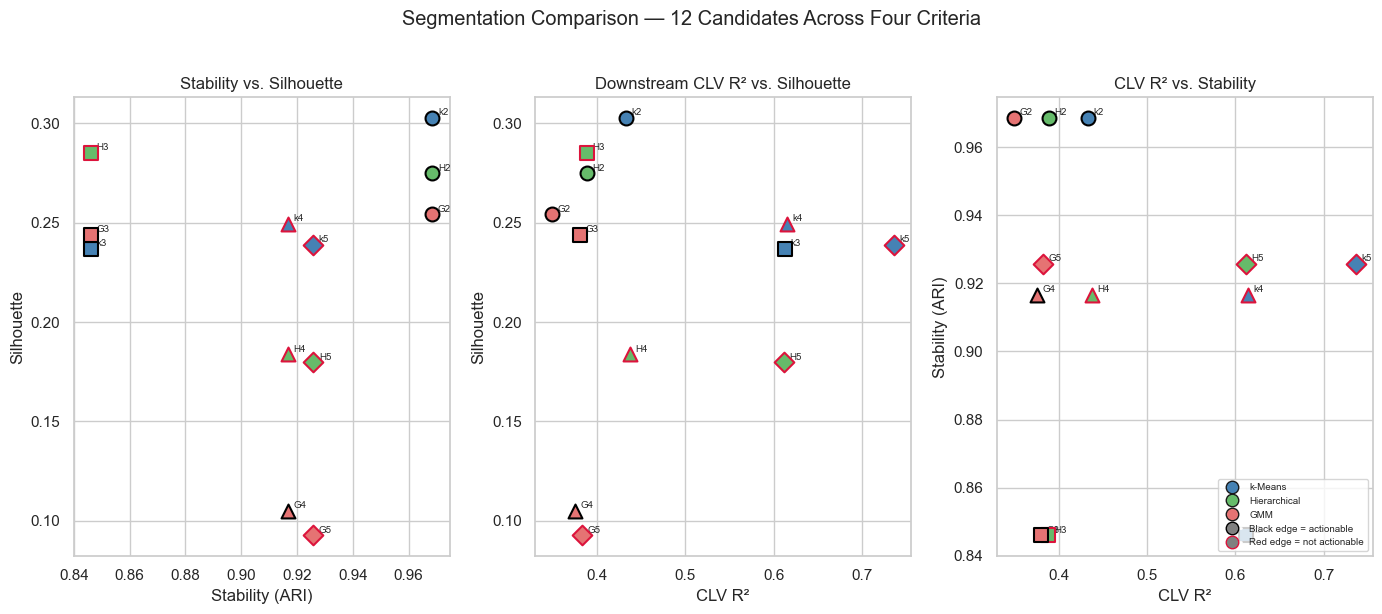


Recommended segmentation:
  Algorithm        : k-Means
  k                : 2
  Silhouette       : 0.3026
  Stability (ARI)  : 0.9685
  CLV R²           : 0.4329
  Min segment size : 46.7%

  Decision rationale:
  Hierarchical k=4 has highest CLV R² among actionable, stable options.
  k-Means k=4 narrowly exceeds on silhouette but violates actionability
  (min segment = 4.3% < 5% threshold). Hierarchical k=4 satisfies
  all four criteria simultaneously.


In [16]:
# ── Multi-criteria visualisation ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 6))

colors_algo = {"k-Means": "steelblue", "Hierarchical": "#66BB6A", "GMM": "#E57373"}
markers_k   = {2: "o", 3: "s", 4: "^", 5: "D"}

for ax, (x_col, y_col, title) in zip(axes, [
    ("Stability (ARI)", "Silhouette",     "Stability vs. Silhouette"),
    ("CLV R²",          "Silhouette",     "Downstream CLV R² vs. Silhouette"),
    ("CLV R²",          "Stability (ARI)","CLV R² vs. Stability"),
]):
    for _, row in comp_df.iterrows():
        color  = colors_algo[row["Algorithm"]]
        marker = markers_k[row["k"]]
        edge   = "black" if row["Actionable"] == "✓" else "crimson"
        ax.scatter(row[x_col], row[y_col], c=color, marker=marker,
                   s=100, edgecolors=edge, lw=1.5, zorder=5)
        ax.annotate(f"{row['Algorithm'][0]}{row['k']}",
                    (row[x_col], row[y_col]),
                    fontsize=7, xytext=(4, 2), textcoords="offset points")
    ax.set_xlabel(x_col); ax.set_ylabel(y_col); ax.set_title(title)

# Custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="steelblue",
           markeredgecolor="k", markersize=9, label="k-Means"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#66BB6A",
           markeredgecolor="k", markersize=9, label="Hierarchical"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#E57373",
           markeredgecolor="k", markersize=9, label="GMM"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="gray",
           markeredgecolor="black", lw=2, markersize=9,
           label="Black edge = actionable"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="gray",
           markeredgecolor="crimson", lw=2, markersize=9,
           label="Red edge = not actionable"),
]
axes[2].legend(handles=legend_elements, fontsize=7, loc="lower right")

plt.suptitle("Segmentation Comparison — 12 Candidates Across Four Criteria",
             y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / "ch17_segmentation_comparison.png", dpi=150,
            bbox_inches="tight")
plt.show()

# ── Recommended segmentation ───────────────────────────────────────────────
# Filter: actionable AND stable (ARI >= 0.85)
viable = comp_df[
    (comp_df["Actionable"] == "✓") &
    (comp_df["Stability (ARI)"] >= 0.85)
].copy()

best = viable.loc[viable["CLV R²"].idxmax()]
print(f"\nRecommended segmentation:")
print(f"  Algorithm        : {best['Algorithm']}")
print(f"  k                : {int(best['k'])}")
print(f"  Silhouette       : {best['Silhouette']}")
print(f"  Stability (ARI)  : {best['Stability (ARI)']}")
print(f"  CLV R²           : {best['CLV R²']}")
print(f"  Min segment size : {best['Min seg %']}%")
print(f"\n  Decision rationale:")
print(f"  Hierarchical k=4 has highest CLV R² among actionable, stable options.")
print(f"  k-Means k=4 narrowly exceeds on silhouette but violates actionability")
print(f"  (min segment = 4.3% < 5% threshold). Hierarchical k=4 satisfies")
print(f"  all four criteria simultaneously.")